# Albumentations库用法

In [1]:
# 元素图片和标签

In [2]:
# 我们需要的语义分割标签一般来说是8位灰度图
# 0,1,2,3...
import matplotlib.pyplot as plt
from PIL import Image

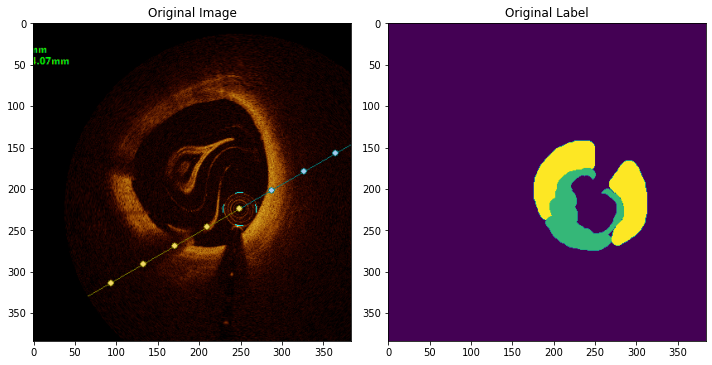

In [3]:
# 读取图片和标签
img = Image.open(r"oct_img.png")
label = Image.open(r"oct_label.png")
# 创建子图
fig,(ax1,ax2) = plt.subplots(1,2,figsize=(10,5))

# 显示原始图像
ax1.imshow(img)
ax1.set_title("Original Image")
# 显示标签
ax2.imshow(label)
ax2.set_title("Original Label")
plt.tight_layout()
plt.show()

In [4]:
# %pip install albumentations

In [5]:
import numpy as np

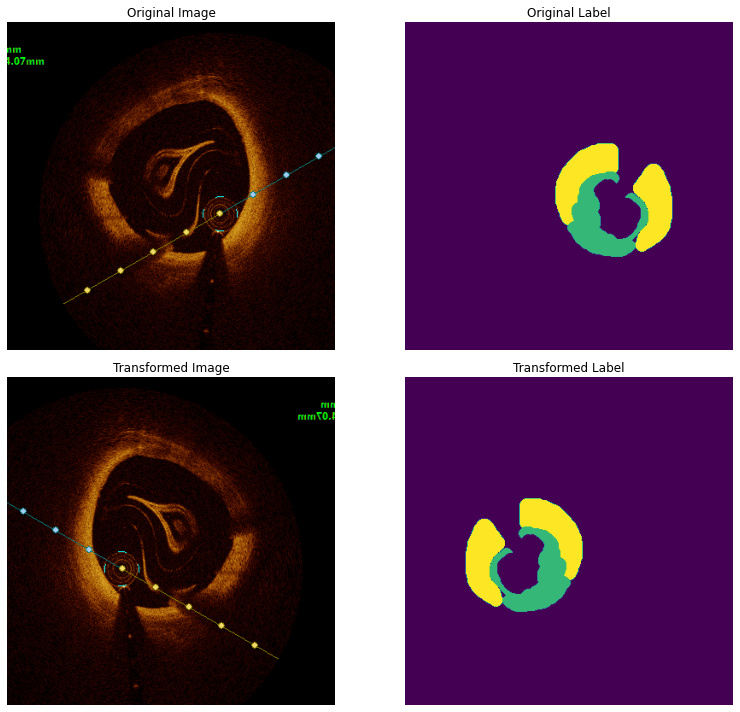

In [6]:
import albumentations as A
# 读取原图
img = Image.open(r"oct_img.png")
label = Image.open(r"oct_label.png")

# 2.将PIL格式图像和标签转为numpy数组，因为albumentations需要Numpy格式
img_np = np.array(img)
label_np = np.array(label)

# 1.定义argmentation对象
transform = A.Compose([
    A.HorizontalFlip(p=1),
])

# 3.应用argmentation对象
transformed = transform(image=img_np,mask=label_np)
img_transformed = transformed['image']
label_transformed = transformed['mask']

# 画图显示处理
fig,axes = plt.subplots(2,2,figsize=(12,10))

# 显示原图
axes[0,0].imshow(img)
axes[0,0].set_title("Original Image")
axes[0,0].axis("off")

# 显示标签
axes[0,1].imshow(label)
axes[0,1].set_title("Original Label")
axes[0,1].axis("off")


# 显示变换后的图像
axes[1,0].imshow(img_transformed)
axes[1,0].set_title("Transformed Image")
axes[1,0].axis("off")

# 显示变换后的标签
axes[1,1].imshow(label_transformed)
axes[1,1].set_title("Transformed Label")
axes[1,1].axis("off")

plt.tight_layout()
plt.show()

# Unet皮肤病实战

In [7]:
# 语义分割Unet:
# 1.数据集准备：我们使用的是ISIC2018的皮肤病变数据集，然后我们按照8:2划分训练和验证
# 2.数据与处理了：我将图像调整到256*256大小，并且使用我们的Albumentations库做数据增强
# 3.网络构建：我们自己手写一个Unet网络，编码器encoder、解码器decoder、跳跃连接
# 4.模型训练：对模型进行评估，比如使用dice系数，保存模型参数
# 5.效果评估：验证一下模型效果，可视化一下结果

In [8]:
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim

import albumentations as A
import matplotlib.pyplot as plt
from torch.utils.data import Dataset,DataLoader,Subset
import os
import cv2
from tqdm import tqdm

In [9]:
# 定义一些超参数
# 2594张图像和对应的标签
IMG_PATH = r"D:\ai code\isic2018\ISIC2018_Task1-2_Training_Input"
MASK_PATH = r"D:\ai code\isic2018\ISIC2018_Task1_Training_GroundTruth"

device = "cuda" if torch.cuda.is_available() else "cpu"
batch_size = 4
size = 112
learning_rate = 0.001
num_epochs = 5


In [10]:
import torch.nn.functional as F

## 构建Unet网络

In [11]:
class UNet(nn.Module):
    def __init__(self,n_channels,n_classes):
        super(UNet,self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        
        # 构造我们需要的网络层
        
        #1.encoder部分
        self.conv1 = nn.Conv2d(self.n_channels,64,kernel_size=3,padding=1)
        self.conv2 = nn.Conv2d(64,128,kernel_size=3,padding=1)
        self.conv3 = nn.Conv2d(128,256,kernel_size=3,padding=1)
        self.conv4 = nn.Conv2d(256,512,kernel_size=3,padding=1)
        self.conv5 = nn.Conv2d(512,1024,kernel_size=3,padding=1)
        
        # 下采样池化
        self.pool = nn.MaxPool2d(kernel_size=2,stride=2)
        
        # 2.decoder部分需要用到的层
        self.upconv1 = nn.ConvTranspose2d(1024,512,kernel_size=2,stride=2)
        self.conv6 = nn.Conv2d(1024,512,kernel_size=3,padding=1)
        self.upconv2 = nn.ConvTranspose2d(512,256,kernel_size=2,stride=2)
        self.conv7 = nn.Conv2d(512,256,kernel_size=3,padding=1)
        self.upconv3 = nn.ConvTranspose2d(256,128,kernel_size=2,stride=2)
        self.conv8 = nn.Conv2d(256,128,kernel_size=3,padding=1)
        self.upconv4 = nn.ConvTranspose2d(128,64,kernel_size=2,stride=2)
        self.conv9 = nn.Conv2d(128,64,kernel_size=3,padding=1)
        self.conv10 = nn.Conv2d(64,self.n_classes,kernel_size=1)
        
        
    def forward(self,x):
        # debug
#         print("x.shape = ",x.shape)
        # encoder
        x1 = F.relu(self.conv1(x))
#         print("x1.shape = ",x1.shape)
        x2 = F.relu(self.conv2(self.pool(x1)))
        x3 = F.relu(self.conv3(self.pool(x2)))
        x4 = F.relu(self.conv4(self.pool(x3)))
        x5 = F.relu(self.conv5(self.pool(x4)))
        
        # decoder
        x6 = F.relu(self.upconv1(x5))
        x6 = torch.cat([x4,x6],dim=1) # B,C,H,W
        x6 = F.relu(self.conv6(x6))
        
        x7 = F.relu(self.upconv2(x6))
        x7 = torch.cat([x3,x7],dim=1)
        x7 = F.relu(self.conv7(x7))
        
        x8 = F.relu(self.upconv3(x7))
        x8 = torch.cat([x2,x8],dim=1)
        x8 = F.relu(self.conv8(x8))
        
        x9 = F.relu(self.upconv4(x8))
        x9 = torch.cat([x1,x9],dim=1)
        x9 = F.relu(self.conv9(x9))
        
        x10 = self.conv10(x9)
#         print("x10.shape = ",x10.shape)
        return x10

In [12]:
unet = UNet(n_channels=3,n_classes=5)

In [13]:
unet

UNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (upconv1): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2))
  (conv6): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upconv2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
  (conv7): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upconv3): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (conv8): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upconv4): ConvTranspose2d(128, 64, kernel_size=(2, 2)

In [14]:
# 模拟一下网络的前向传播
inputs = torch.randn((2,3,224,224))
inputs.shape

torch.Size([2, 3, 224, 224])

In [15]:
outputs = unet(inputs)
outputs.shape

torch.Size([2, 5, 224, 224])

In [16]:
class ISICDataset(Dataset):
    """
    参数:
    images_path: 图像文件夹路径
    masks_path: 标签文件夹路径
    size: 图像最终大小(因为我们要使用gpu并行，前提条件就是图像大小统一)
    tranform: 对图像和标签做的数据增强
    ids: 图像的id列表
    """
    def __init__(self,images_path,masks_path,size,tranform=None,ids=None):
        self.images_path = images_path
        self.masks_path = masks_path
        self.size = size
        self.tranform = tranform
        
        # 如果没有指定ids，则使用文件夹中所有的图像
        if ids is None:
            # ISIC_0000099
            [image_file[:-4] for image_file in os.listdir(images_path) if image_file.endswith(".jpg")]
        else:
            self.ids = ids
    def __getitem__(self,idx):
        # 获取图像和标签对
        # ISIC_0000000.jpg
        image_path = os.path.join(self.images_path,self.ids[idx] + '.jpg')
        # ISIC_0000000_segmentation.png
        mask_path = os.path.join(self.masks_path,self.ids[idx]+"_segmentation.png")
        
        # 读取图像和对应的标签
        img = cv2.imread(image_path,cv2.IMREAD_COLOR)
        mask = cv2.imread(mask_path,cv2.IMREAD_GRAYSCALE)
#         print("mask转换前 = ",np.unique(mask))
        # BGR -> RGB
        img = cv2.cvtColor(img,cv2.COLOR_BGR2RGB)
        ret,mask = cv2.threshold(mask,127,255,cv2.THRESH_BINARY)
#         print("mask转换后 = ",np.unique(mask))
        
        # 做数据增强
        if self.tranform:
            augmentations = self.tranform(image=img,mask=mask)
            img = augmentations['image']
            mask = augmentations['mask']
        
        # 最终上面一顿操作的结果其实是numpy
        # 但是我们需要使用pytorch框架
        # numpy -> tensor
#         print("转换前图像的形状img.shape = ",img.shape)
        # b,h,w,c -> b,c,h,w(pytorch需要的格式)
        # 0-1
        img = torch.from_numpy(img).permute(2,0,1).float()/255
#         mask = torch.from_numpy(mask).unsqueeze(0)
        mask = torch.from_numpy(mask).long()
        # 把255转为1
        mask[mask == 255] = 1
#         print("最终mask = ",np.unique(mask.numpy()))
        return img,mask
       
        
    def __len__(self):
        return len(self.ids)

In [17]:
# IMG_PATH = r"D:\ai code\isic2018\ISIC2018_Task1-2_Training_Input"
# MASK_PATH = r"D:\ai code\isic2018\ISIC2018_Task1_Training_GroundTruth"

# device = "cuda" if torch.cuda.is_available() else "cpu"
# batch_size = 2
# size = 112
# learning_rate = 0.001
# num_epochs = 2

In [18]:
# 创建数据增强对象
tranform = A.Compose([
    A.Resize(height=size,width=size),
    A.Rotate(limit=35,p=0.5),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
])

test_tranform = A.Compose([
    A.Resize(height=size,width=size),
])

In [19]:
# 获取图片ids
all_ids = [image_file[:-4] for image_file in os.listdir(IMG_PATH) if image_file.endswith(".jpg")]

# 随机打乱
np.random.shuffle(all_ids)

# 训练和验证 8:2
split_ids = int(0.8*len(all_ids))

# 获取训练的ids和验证的ids
train_ids = all_ids[:split_ids]
test_ids = all_ids[split_ids:]

In [20]:
len(train_ids),len(test_ids)

(2075, 519)

In [21]:
train_ids[:5]

['ISIC_0015403',
 'ISIC_0013487',
 'ISIC_0010251',
 'ISIC_0013836',
 'ISIC_0014783']

In [22]:
test_ids[:5]

['ISIC_0015023',
 'ISIC_0000125',
 'ISIC_0013488',
 'ISIC_0013808',
 'ISIC_0010552']

In [23]:
# 创建训练和测试数据集
# 参数:
# images_path: 图像文件夹路径
# masks_path: 标签文件夹路径
# size: 图像最终大小(因为我们要使用gpu并行，前提条件就是图像大小统一)
# tranform: 对图像和标签做的数据增强
# ids: 图像的id列表
train_dataset = ISICDataset(images_path=IMG_PATH,
            masks_path=MASK_PATH,
            size=size,
            tranform=tranform,
            ids=train_ids)

test_dataset = ISICDataset(images_path=IMG_PATH,
            masks_path=MASK_PATH,
            size=size,
            tranform=test_tranform,
            ids=test_ids)

In [24]:
# 创建Dataloader
train_loader = DataLoader(train_dataset,batch_size=batch_size,shuffle=True)
test_loader = DataLoader(test_dataset,batch_size=1,shuffle=False)

In [25]:
# 创建模型开始训练
model = UNet(n_channels=3, n_classes=2)
model.to(device)

UNet(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv2): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv3): Conv2d(128, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv4): Conv2d(256, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (conv5): Conv2d(512, 1024, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (upconv1): ConvTranspose2d(1024, 512, kernel_size=(2, 2), stride=(2, 2))
  (conv6): Conv2d(1024, 512, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upconv2): ConvTranspose2d(512, 256, kernel_size=(2, 2), stride=(2, 2))
  (conv7): Conv2d(512, 256, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upconv3): ConvTranspose2d(256, 128, kernel_size=(2, 2), stride=(2, 2))
  (conv8): Conv2d(256, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (upconv4): ConvTranspose2d(128, 64, kernel_size=(2, 2)

In [26]:
# 创建损失函数和优化器
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(),lr=learning_rate)

best_dice = 0. # 记录最好的dice

In [28]:
for epoch in range(num_epochs):
    print("第epoch = ",epoch)
    # 训练阶段
    model.train()
    train_loss = 0.
    loop = tqdm(enumerate(train_loader),total=len(train_loader))
    for batch_idx,(images,masks) in loop:
        # 把图像和标签放到cuda上
        images,masks = images.to(device),masks.to(device)
        
        # 梯度清零
        optimizer.zero_grad()
        
        # 前向传播
        outputs = model(images)
        loss = criterion(outputs,masks)
        
        # 反向传播，更新参数
        loss.backward()
        optimizer.step()
        
        # 记录一下loss
        train_loss += loss.item()
        loop.set_description(f"Epoch[{epoch+1}/{num_epochs}]")
        loop.set_postfix(loss=loss.item())
    
    avg_train_loss = train_loss/len(train_loader)
    
    # 验证阶段
    model.eval()
    dice_score = 0.
    
    with torch.no_grad():
        for images,labes in test_loader:
            images = images.to(device)
            masks = masks.to(device)
            
            # 前向传播
            outputs = model(images)
#             preds = torch.sigmoid(outputs)
            
            preds = torch.argmax(outputs,dim=1)
            
            # 计算当前batch的dice
            dice = (2*(preds * masks).sum())/((preds+masks).sum() + 1e-8)
            dice_score += dice.item()
    # 计算平均dice_score
    avg_dice = dice_score/len(test_loader)
    
    print(f"Epoch {epoch+1}/{num_epochs}")
    print(f"avg_train_loss: {avg_train_loss:.4f}")
    print(f"Test avg_dice: {avg_dice:.4f}")
    
    # 保存最近的模型
    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(),"best.pth")
        print(f"Best dice: {best_dice:.4f}")
    
    print("-"*50)
    

第epoch =  0


Epoch[1/5]: 100%|████████████████████████████████████████████████████████| 519/519 [08:15<00:00,  1.05it/s, loss=0.304]


Epoch 1/5
avg_train_loss: 0.2706
Test avg_dice: 0.3485
Best dice: 0.3485
--------------------------------------------------
第epoch =  1


Epoch[2/5]: 100%|████████████████████████████████████████████████████████| 519/519 [08:23<00:00,  1.03it/s, loss=0.385]


Epoch 2/5
avg_train_loss: 0.2306
Test avg_dice: 0.3975
Best dice: 0.3975
--------------------------------------------------
第epoch =  2


...

Epoch 3/5
avg_train_loss: 0.2059
Test avg_dice: 0.3836
--------------------------------------------------
第epoch =  3


Epoch[4/5]: 100%|████████████████████████████████████████████████████████| 519/519 [08:26<00:00,  1.02it/s, loss=0.125]


Epoch 4/5
avg_train_loss: 0.1881
Test avg_dice: 0.4097
Best dice: 0.4097
--------------------------------------------------
第epoch =  4


Epoch[5/5]: 100%|███████████████████████████████████████████████████████| 519/519 [08:21<00:00,  1.04it/s, loss=0.0854]


Epoch 5/5
avg_train_loss: 0.1880
Test avg_dice: 0.2952
--------------------------------------------------


In [38]:
def check_model_dice(loader,model,device="cuda"):
    num_correct = 0
    dice_score = 0
    # 在推理阶段一定要设置为eval模式
    model.eval()
    
    with torch.no_grad():
        for x,y in loader:
            x = x.to(device)
            y = y.to(device)
            preds = model(x)
            preds = torch.softmax(preds,dim=1)
            preds = torch.argmax(preds,dim=1)
            
            # num_correct += (preds == y).sum()
            dice_score += (2 * (preds * y).sum()) / ((preds + y).sum() + 1e-8)
    print(f"Dice score: {dice_score/len(loader)}")

    

In [39]:
# 加载最优模型参数
best_state_dict = torch.load("best.pth")
model.load_state_dict(best_state_dict)

<All keys matched successfully>

In [40]:
check_model_dice(test_loader,model,device)

Dice score: 0.8122981786727905


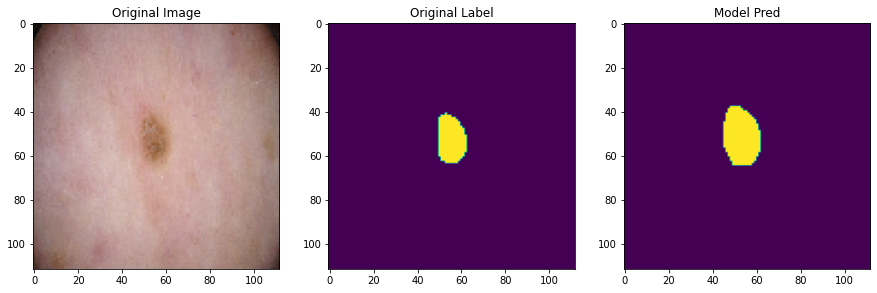

In [48]:
# 可视化一张图像的原图、标签、预测
img, true_mask = test_dataset[15]

# matplotlib -> numpy: h,w,c
# c,h,w -> h,w,c(numpy)
img = img.permute(1,2,0).numpy()
true_mask = true_mask.numpy()


# 得到这张图像的预测图
with torch.no_grad():
    img_tensor = torch.Tensor(img).unsqueeze(0).permute(0,3,1,2).to(device)
#     print(img_tensor.shape)
    generated_mask = model(img_tensor)
    generated_mask = torch.argmax(generated_mask,dim=1)
    generated_mask = generated_mask.squeeze().cpu().numpy()

# 画图
fig,ax = plt.subplots(1,3,figsize=(15,5))

ax[0].imshow(img)
ax[0].set_title("Original Image")

ax[1].imshow(true_mask)
ax[1].set_title("Original Label")

ax[2].imshow(generated_mask)
ax[2].set_title("Model Pred")

# plt.savefig("Pred.png")
plt.show()
